# 05 — Gower dissimilarity

| | |
|---|---|
| Author | Abdulla Almannaee |
| Task | 34 — Add a mixed-type dissimilarity |
| Contributes to | `xxcluster/measures/dissimilarity/gower.py` |
| Documents | `documentation/sections/clustering_methods/measures/01-gower.tex`, Sect. 7.1 |
| Date | 14 September 2026 |

Based on `00-template.ipynb`; the ten sections retain their original order.
This is an executed test bed and evidence record. The data are **synthetic**, not an AquaBlend extract.

Execution: all cells ran sequentially in a fresh in-process IPython session, with rich outputs captured. Ordinary Jupyter kernel startup is blocked by this environment’s socket restrictions; run Restart & Run All in the project kernel before submission.

AI assistance: OpenAI Codex assisted with implementation, tests, documentation and notebook construction. The named contributor must review the work and make the declaration required by the university before submission.

## 1. Setup

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "xxcluster").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.utils.estimator_checks import check_estimator

import xxcluster
from xxcluster.core.registry import REGISTRY
from xxcluster.core.validation import check_dissimilarity_matrix
from xxcluster.evaluation.protocol import Environment, Protocol, RunResult
from xxcluster.evaluation.report import ComparisonTable
from xxcluster.io.datasets import FeatureSpec
from xxcluster.io.loaders import FrameLoader
from xxcluster.measures.dissimilarity import Gower
from xxcluster.measures.validation.internal import Silhouette

RANDOM_STATE = 42
env = Environment.capture()
print(env.summary())
print("Revision:", env.revision)

Python 3.13.9 (matplotlib 3.10.6, numpy 2.3.5, pandas 2.3.3, scikit-learn 1.7.2, scipy 1.16.3), 9c59665-dirty
Revision: 9c59665-dirty


## 2. Scope

Test whether Gower produces a symmetric, zero-diagonal dissimilarity in [0, 1] on mixed, incomplete observations, with scalar and rectangular paths agreeing. Demonstrate actual average-linkage clustering through `metric="precomputed"`, without imputation or one-hot encoding.

Negative results defined before the experiment: a property/assertion failure, an undefined pair, failure to produce a partition, or adjusted Rand agreement below 0.80 with the planted synthetic groups. A resampling ARI below 0.80 indicates that the selected partition is sensitive to sampling. These thresholds are illustrative diagnostic choices, not published performance requirements.

The measure is not asserted to be metric: Section 5 deliberately exhibits a triangle-inequality violation. Task 40's Ward guard is a separate dependency: backend rejection is not evidence that an absent `xxcluster` guard works.

## 3. Data

Generate 90 synthetic observations in three planted groups, with two numeric measurements, a nominal source category, ordered treatment priority, an asymmetric binary alarm, and a constant numeric column. Retain pH in every row to guarantee some comparable information. Independently mask 25% of each of four other modelling columns using the fixed seed; this is a controlled missingness experiment, not an estimate of operational missingness.

The generator creates illustrative values, not measured water samples. The planted label is held back as `interpret`; the identifier never enters Gower. The constant column deliberately exercises zero-range exclusion. All values enter through `FrameLoader` with an explicit schema and provenance.

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
truth = np.repeat(np.arange(3), 30)
m = len(truth)
source_levels = np.array(["river", "groundwater", "reclaimed"], dtype=object)
priority_levels = np.array(["low", "medium", "high"], dtype=object)
source = source_levels[truth].copy()
flips = rng.random(m) < 0.15
source[flips] = rng.choice(source_levels, flips.sum())
frame = pd.DataFrame({
    "sample_id": [f"synthetic-{i:03d}" for i in range(m)],
    "ph": np.array([6.8, 7.4, 8.1])[truth] + rng.normal(0, 0.08, m),
    "turbidity_ntu": np.maximum(0, np.array([2., 12., 35.])[truth] + rng.normal(0, 1.5, m)),
    "source_type": source,
    "priority": priority_levels[truth],
    "alarm": (rng.random(m) < np.array([0.05, 0.30, 0.75])[truth]).astype(float),
    "constant_probe": np.ones(m),
    "planted_group": truth,
})
for column in ["turbidity_ntu", "source_type", "priority", "alarm"]:
    frame.loc[rng.random(m) < 0.25, column] = np.nan

schema = [
    FeatureSpec("sample_id", dtype="str", role="identifier"),
    FeatureSpec("ph", unit="pH", valid_range=(0, 14)),
    FeatureSpec("turbidity_ntu", unit="NTU", valid_range=(0, None)),
    FeatureSpec("source_type", dtype="str"),
    FeatureSpec("priority", dtype="str"),
    FeatureSpec("alarm", valid_range=(0, 1)),
    FeatureSpec("constant_probe"),
    FeatureSpec("planted_group", dtype="int", role="interpret"),
]
dataset = FrameLoader(
    frame, schema,
    description="Task 34 seeded synthetic mixed-type fixture; no operational records",
).load()
X = dataset.cluster_matrix()
original = X.copy(deep=True)
missing_before = int(X.isna().to_numpy().sum())
assert missing_before > 0
assert dataset.check_ranges().empty
assert "planted_group" not in X and "sample_id" not in X
print(dataset.provenance_statement())
print("Rows:", len(X), "Modelling columns:", X.shape[1], "Missing cells:", missing_before)
display(X.head(8))
display(X.isna().sum().rename("missing_cells").to_frame())

Data from Task 34 seeded synthetic mixed-type fixture; no operational records, with no cutoff recorded, retrieved 2026-09-14T04:01:39+00:00. 90 observations over 6 clustering features.
Rows: 90 Modelling columns: 6 Missing cells: 90


,ph,turbidity_ntu,source_type,priority,alarm,constant_probe
0,6.684231,NaN,river,NaN,0.0,1.0
1,6.694184,2.274852,river,low,NaN,1.0
2,6.720220,0.163296,river,low,0.0,1.0
3,6.831982,0.000000,NaN,low,0.0,1.0
4,6.727562,4.476392,reclaimed,low,NaN,1.0
5,6.769747,4.585499,river,NaN,0.0,1.0
6,6.903938,1.730721,river,NaN,0.0,1.0
7,6.771499,1.425219,NaN,low,0.0,1.0


,missing_cells
ph,0
turbidity_ntu,27
source_type,22
priority,18
alarm,23
constant_probe,0


## 4. Protocol

Use the guide's shared seed, ten restarts and candidate counts 2–10, with silhouette as the shared index and no preprocessing. Average linkage is deterministic, so repeated identical fits are unnecessary. The ten seeded subsampling runs below assess perturbation, not optimiser restarts.

Explicit deviations: use scikit-learn's real `AgglomerativeClustering` backend directly because this revision has no concrete precomputed `xxcluster` clusterer. Score using `Silhouette.score(..., metric="precomputed")`: `ComparisonRun._score` does not forward the metric and would score rows of the distance matrix with Euclidean distance. Construct a `RunResult` from the explicit, correct score and use the shared `ComparisonTable` exporter. No base-class or evaluation code is changed.

Use equal feature weights and declared ordinal levels. The ordinal option is an equally spaced level-rank extension, not Podani's tie-adjusted formula. Values outside a fitted numeric range saturate at 1; fitted zero-range and entirely missing columns remain inactive until refitting.

In [3]:
protocol = Protocol(
    indices=["silhouette"], n_restarts=10, random_state=RANDOM_STATE,
    preprocessing=None, n_clusters_candidates=range(2, 11), environment=env,
)
measure = Gower(
    feature_types=["numeric", "numeric", "categorical", "ordinal", "asymmetric_binary", "numeric"],
    weights=[1., 1., 1., 1., 1., 1.],
    ordinal_categories={3: ["low", "medium", "high"]},
)
print(protocol.describe())
print("No imputer, encoder or external scaler is used.")

Every method is scored on silhouette, reported in that order. Stochastic methods are given 10 restarts each, and the best run by the method's own criterion is retained. Where the number of clusters must be fixed in advance it is swept over 2--10. The root random seed is 42; per-run seeds are derived from it, so the whole experiment replays from that one value. Run under Python 3.13.9 (matplotlib 3.10.6, numpy 2.3.5, pandas 2.3.3, scikit-learn 1.7.2, scipy 1.16.3), 9c59665-dirty.
No imputer, encoder or external scaler is used.


## 5. Contract check

In [4]:
check_estimator(Gower())
assert clone(measure).get_params() == measure.get_params()
assert not measure.is_fitted
assert REGISTRY.get("gower") is Gower
measure.fit(X)
D = measure.pairwise(X)
check_dissimilarity_matrix(D)
assert np.isfinite(D).all() and (D >= 0).all() and (D <= 1).all()
np.testing.assert_array_equal(np.diag(D), np.zeros(len(X)))
np.testing.assert_allclose(D, D.T)
np.testing.assert_allclose(measure.pairwise(X.iloc[:7], X.iloc[7:12]), D[:7, 7:12])
assert not measure.active_[-1]
pd.testing.assert_frame_equal(X, original)
print("Estimator checks: passed without exclusions")
print("Matrix properties, rectangular consistency and unchanged incomplete input: passed")
print(measure.capabilities().describe())
display(pd.DataFrame({"feature": X.columns, "range": measure.ranges_, "active": measure.active_}))

Estimator checks: passed without exclusions
Matrix properties, rectangular consistency and unchanged incomplete input: passed
{'family': None, 'subfamily': None, 'backend': 'native', 'assignment': 'crisp', 'is_inductive': False, 'produces_hierarchy': False, 'supports_precomputed': False, 'requires_n_clusters': False, 'handles_noise': False, 'handles_missing': True, 'handles_categorical': True, 'scale_invariant': True, 'deterministic': True, 'scales_to': 'medium', 'time_complexity': 'O(m * n) fit; O(m * m_prime * n) pairwise', 'space_complexity': 'O(m * m_prime + (m + m_prime) * n)'}


,feature,range,active
0,ph,1.608463,True
1,turbidity_ntu,39.357601,True
2,source_type,NaN,True
3,priority,2.000000,True
4,alarm,NaN,True
5,constant_probe,0.000000,False


In [5]:
# Exact golden values, calculated by hand rather than by another Gower package.
golden = np.array([[0, "river", 0], [10, "river", 1], [5, "ground", 0]], dtype=object)
g = Gower(feature_types=["numeric", "categorical", "symmetric_binary"], weights=[2, 1, 1]).fit(golden)
expected = np.array([[0, .75, .5], [.75, 0, .75], [.5, .75, 0]])
np.testing.assert_allclose(g.pairwise(golden), expected)
assert g(golden[0], golden[1]) == expected[0, 1]

# Fourth row fixes nonzero training ranges. First three rows violate the triangle inequality.
triangle = np.array([[0, 0, np.nan], [0, np.nan, 0], [np.nan, 1, 0], [1, 1, 1]])
T = Gower().fit(triangle).pairwise(triangle)
assert T[0, 2] == 1 and T[0, 1] == T[1, 2] == 0
print("Triangle counterexample: d(A,C)=1 > d(A,B)+d(B,C)=0")
print("Distinct partially observed vectors can also have distance zero.")

binary = [[0, 0], [1, 0], [0, 1]]
sym = Gower(feature_types=["numeric", "symmetric_binary"]).fit(binary)
asym = Gower(feature_types=["numeric", "asymmetric_binary"]).fit(binary)
print("Joint-zero treatment:", sym(binary[0], binary[1]), "symmetric;", asym(binary[0], binary[1]), "asymmetric")

try:
    Gower().fit([[0, 0], [1, 1]]).pairwise([[0, np.nan]], [[np.nan, 1]])
except ValueError as exc:
    no_overlap_error = str(exc)
    print("Expected undefined-pair refusal:", no_overlap_error)
else:
    raise AssertionError("No-overlap case must fail explicitly")

try:
    AgglomerativeClustering(n_clusters=2, linkage="ward", metric="precomputed").fit(D)
except ValueError as exc:
    ward_backend_error = str(exc)
    assert "euclidean" in ward_backend_error.lower()
    print("Expected backend Ward refusal:", ward_backend_error)
else:
    raise AssertionError("Ward must not accept this precomputed matrix")

ward_gate_status = "pending: Task 40 Ward is not registered in this checkout"
if "ward" in REGISTRY:
    try:
        REGISTRY.create("ward", n_clusters=2, metric=Gower().fit(triangle)).fit(triangle)
    except ValueError as exc:
        assert "metric" in str(exc).lower()
        ward_gate_status = str(exc)
    else:
        raise AssertionError("Registered Ward accepted a non-metric measure")
print("xxcluster is_metric gate:", ward_gate_status)

Triangle counterexample: d(A,C)=1 > d(A,B)+d(B,C)=0
Distinct partially observed vectors can also have distance zero.
Joint-zero treatment: 0.5 symmetric; 1.0 asymmetric
Expected undefined-pair refusal: No comparable positive-weight features for pair (0, 0). Gower is undefined for non-identical observations with no overlap; review feature coverage rather than impute a distance.
Expected backend Ward refusal: precomputed was provided as metric. Ward can only work with euclidean distances.
xxcluster is_metric gate: pending: Task 40 Ward is not registered in this checkout


## 6. Selection

Sweep the shared 2–10 candidate counts and maximise silhouette computed on Gower dissimilarities. Report the whole curve. Then take ten seeded 80% subsamples without replacement, refit Gower ranges inside each sample, repeat the same selection, and compare the resulting labels with the full-data partition restricted to those rows. This manual resampling is declared because the shared `StabilityAnalysis._fit` remains unimplemented; it measures sampling sensitivity, not external predictive accuracy.

In [6]:
selection_rows = []
for k in protocol.n_clusters_candidates:
    candidate = AgglomerativeClustering(n_clusters=k, linkage="average", metric="precomputed")
    candidate_labels = candidate.fit_predict(D)
    score = Silhouette().score(D, candidate_labels, metric="precomputed")
    selection_rows.append({"n_clusters": k, "silhouette": float(score)})
selection = pd.DataFrame(selection_rows)
best_k = int(selection.loc[selection.silhouette.idxmax(), "n_clusters"])
method = AgglomerativeClustering(n_clusters=best_k, linkage="average", metric="precomputed").fit(D)
labels = method.labels_
display(selection)
print("Selected cluster count:", best_k)

stability_rows = []
for repeat in range(10):
    sample_rng = np.random.default_rng(protocol.seed_for(f"gower:subsample:{repeat}"))
    idx = np.sort(sample_rng.choice(len(X), size=int(.8 * len(X)), replace=False))
    subset = X.iloc[idx]
    try:
        local_measure = clone(measure).fit(subset)  # all fitted ranges re-estimated here
        local_D = local_measure.pairwise(subset)
        candidates = []
        for k in protocol.n_clusters_candidates:
            sublabels = AgglomerativeClustering(n_clusters=k, linkage="average", metric="precomputed").fit_predict(local_D)
            candidates.append((float(Silhouette().score(local_D, sublabels, metric="precomputed")), k, sublabels))
        local_score, local_k, local_labels = max(candidates, key=lambda row: row[0])
        stability_rows.append({"repeat": repeat, "n_clusters": local_k,
                               "ari": float(adjusted_rand_score(labels[idx], local_labels)), "error": None})
    except ValueError as exc:
        stability_rows.append({"repeat": repeat, "n_clusters": np.nan, "ari": np.nan, "error": str(exc)})
stability = pd.DataFrame(stability_rows)
display(stability)
print("Subsample ARI mean / SD:", stability.ari.mean(), stability.ari.std(ddof=1))

,n_clusters,silhouette
0,2,0.652456
1,3,0.811621
2,4,0.749715
3,5,0.694605
4,6,0.727533
5,7,0.637525
6,8,0.589147
7,9,0.640067
8,10,0.608475


Selected cluster count: 3


,repeat,n_clusters,ari,error
0,0,3,1.000000,None
1,1,3,1.000000,None
2,2,3,1.000000,None
3,3,3,1.000000,None
4,4,3,1.000000,None
5,5,3,1.000000,None
6,6,3,1.000000,None
7,7,3,1.000000,None
8,8,3,0.914519,None
9,9,3,1.000000,None


Subsample ARI mean / SD: 0.9914518802477316 0.02703152812904243


## 7. Results

Silhouette is the shared protocol score. Planted-group ARI is a supplementary check available only because this dataset is synthetic; it does not drive selection. Profiles remain in original measurement units and show observed counts, so missing observations are not silently treated as measurements.

In [7]:
silhouette = float(Silhouette().score(D, labels, metric="precomputed"))
truth_ari = float(adjusted_rand_score(dataset.interpretation_frame()["planted_group"], labels))
result = RunResult(
    method="Gower + average", params={"n_clusters": best_k, "metric": "precomputed", "linkage": "average"},
    scores={"silhouette": silhouette}, n_clusters_found=int(np.unique(labels).size),
)
table = ComparisonTable([result])
display(table.quantitative())
print("Supplementary ARI against planted groups:", truth_ari)
print("Predeclared recovery threshold met:", truth_ari >= .80)
print("Predeclared stability threshold met:", bool(stability.ari.ge(.80).all() and stability.error.isna().all()))
profiles = X.assign(cluster=labels).groupby("cluster").agg(
    rows=("ph", "size"), ph_mean=("ph", "mean"),
    turbidity_observed=("turbidity_ntu", "count"), turbidity_mean=("turbidity_ntu", "mean"),
    source_observed=("source_type", "count"), alarm_observed=("alarm", "count"),
)
display(profiles)
pd.testing.assert_frame_equal(X, original)
assert int(X.isna().to_numpy().sum()) == missing_before
print("Missing values remain:", missing_before, "— no imputation performed.")

,silhouette,n_clusters_found
method,,
Gower + average,0.811621,3


Supplementary ARI against planted groups: 1.0
Predeclared recovery threshold met: True
Predeclared stability threshold met: True


,rows,ph_mean,turbidity_observed,turbidity_mean,source_observed,alarm_observed
cluster,,,,,,
0,30,6.786869,25,1.821428,24,24
1,30,8.109145,20,35.564039,21,20
2,30,7.385815,18,11.580947,23,23


Missing values remain: 90 — no imputation performed.


## 8. Figures

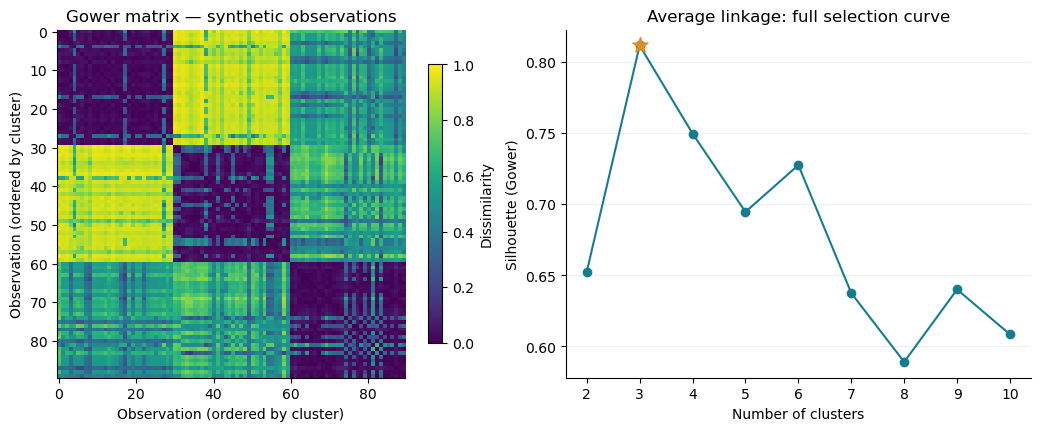

In [8]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
order = np.argsort(labels, kind="stable")
im = axes[0].imshow(D[np.ix_(order, order)], cmap="viridis", vmin=0, vmax=1)
axes[0].set(title="Gower matrix — synthetic observations", xlabel="Observation (ordered by cluster)", ylabel="Observation (ordered by cluster)")
fig.colorbar(im, ax=axes[0], label="Dissimilarity", shrink=.8)
axes[1].plot(selection.n_clusters, selection.silhouette, "o-", color="#147d92")
axes[1].scatter([best_k], [silhouette], s=130, marker="*", color="#e28d23", zorder=3)
axes[1].set(title="Average linkage: full selection curve", xlabel="Number of clusters", ylabel="Silhouette (Gower)", xticks=list(protocol.n_clusters_candidates))
axes[1].grid(axis="y", alpha=.2)
FIGURES = ROOT / "documentation" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES / "gower-evidence.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Export

Export the results table with the shared exporter. The evidence JSON records the protocol, environment, declared modelling choices, source hashes, dependency limitations and numerical checks. LaTeX macros are generated from these values; the write-up does not retype the results.

In [9]:
TABLES = ROOT / "documentation" / "tables"
TABLES.mkdir(parents=True, exist_ok=True)
table.to_csv(TABLES / "gower-results.csv")
table.to_latex(TABLES / "gower-results.tex", columns=["silhouette", "n_clusters_found"])
selection.to_csv(TABLES / "gower-selection.csv", index=False)
stability.to_csv(TABLES / "gower-stability.csv", index=False)
profiles.to_csv(TABLES / "gower-profiles.csv")
summary = {
    "observations": len(X), "features": X.shape[1], "missing_cells": missing_before,
    "missing_percent": 100 * missing_before / X.size, "selected_k": best_k,
    "silhouette": silhouette, "planted_ari": truth_ari,
    "stability_ari_mean": float(stability.ari.mean()), "stability_ari_sd": float(stability.ari.std(ddof=1)),
    "stability_failures": int(stability.error.notna().sum()),
    "ward_backend_error": ward_backend_error, "ward_is_metric_gate": ward_gate_status,
    "no_overlap_error": no_overlap_error,
}
source_paths = ["xxcluster/measures/dissimilarity/gower.py", "tests/test_gower.py"]
evidence = {
    "execution": "Fresh in-process IPython session; standard Jupyter sockets unavailable",
    "protocol": protocol.to_dict(), "data_provenance": dict(dataset.provenance),
    "measure_params": measure.get_params(), "summary": summary,
    "source_sha256": {p: hashlib.sha256((ROOT / p).read_bytes()).hexdigest() for p in source_paths},
    "caveats": [
        "Synthetic fixture; no operational AquaBlend claims.",
        "One fully observed active feature ensures pairwise coverage in this fixture.",
        "Manual backend fitting and explicit precomputed silhouette bypass missing metric forwarding in ComparisonRun.",
        "Manual resampling with refitted Gower ranges replaces unimplemented StabilityAnalysis.",
        "Ward is_metric integration awaits Task 40; sklearn rejection is a separate check.",
        "Ordinal distances assume equally spaced declared ranks, not Podani tie correction.",
        "Gower, Podani and backend documentation citation keys await shared-sheet assignment.",
    ],
}
(TABLES / "gower-evidence.json").write_text(json.dumps(evidence, indent=2, allow_nan=False) + "\n")
values = {
    "GowerRows": str(len(X)), "GowerMissing": str(missing_before),
    "GowerMissingPercent": f"{summary['missing_percent']:.1f}",
    "GowerSelectedK": str(best_k), "GowerSilhouette": f"{silhouette:.4f}",
    "GowerPlantedARI": f"{truth_ari:.4f}", "GowerStabilityMean": f"{summary['stability_ari_mean']:.4f}",
    "GowerStabilitySD": f"{summary['stability_ari_sd']:.4f}",
    "GowerStabilityFailures": str(summary["stability_failures"]),
}
macros = "% Generated by notebooks/05-gower.ipynb; do not edit by hand.\n"
macros += "".join("\\newcommand{\\" + key + "}{" + value + "}\n" for key, value in values.items())
(TABLES / "gower-summary.tex").write_text(macros)
print(json.dumps(summary, indent=2))
print("Exported results, selection, stability, profiles, summary macros and evidence metadata.")

{
  "observations": 90,
  "features": 6,
  "missing_cells": 90,
  "missing_percent": 16.666666666666668,
  "selected_k": 3,
  "silhouette": 0.8116210458904581,
  "planted_ari": 1.0,
  "stability_ari_mean": 0.9914518802477316,
  "stability_ari_sd": 0.02703152812904243,
  "stability_failures": 0,
  "ward_backend_error": "precomputed was provided as metric. Ward can only work with euclidean distances.",
  "ward_is_metric_gate": "pending: Task 40 Ward is not registered in this checkout",
  "no_overlap_error": "No comparable positive-weight features for pair (0, 0). Gower is undefined for non-identical observations with no overlap; review feature coverage rather than impute a distance."
}
Exported results, selection, stability, profiles, summary macros and evidence metadata.


## 10. Findings and caveats

Each result below points to the paragraph it supports. The table is rendered from the executed values. Failed or unstable results remain in the record.

In [10]:
display(Markdown(f"""
| Evidence | Write-up paragraph | Finding |
|---|---|---|
| Section 5 golden values and matrix assertions | Definition / Properties | Scalar, rectangular and square results agree; all tested matrix properties pass. |
| Section 5 counterexample | Properties / Behaviour | Triangle inequality and separation of distinct incomplete vectors fail; `is_metric=False` is required. |
| Sections 3 and 7 unchanged input | Application | {missing_before} missing cells remain in {len(X)} synthetic observations; no imputation or one-hot encoding. |
| Section 6 selection; Section 7 result | Behaviour | Selected {best_k} clusters; Gower silhouette {silhouette:.4f}; supplementary planted-group ARI {truth_ari:.4f}. |
| Section 6 resampling | Behaviour / Limitations | Subsample ARI {stability.ari.mean():.4f} ± {stability.ari.std(ddof=1):.4f}; {int(stability.error.notna().sum())} failed runs. |
| Section 5 backend refusal | Limitations | sklearn Ward rejects precomputed input; the repository's `is_metric` guard remains pending Task 40. |
| Section 8 | Behaviour | `gower-evidence.png` shows the distance matrix and all candidate scores. |
"""))


| Evidence | Write-up paragraph | Finding |
|---|---|---|
| Section 5 golden values and matrix assertions | Definition / Properties | Scalar, rectangular and square results agree; all tested matrix properties pass. |
| Section 5 counterexample | Properties / Behaviour | Triangle inequality and separation of distinct incomplete vectors fail; `is_metric=False` is required. |
| Sections 3 and 7 unchanged input | Application | 90 missing cells remain in 90 synthetic observations; no imputation or one-hot encoding. |
| Section 6 selection; Section 7 result | Behaviour | Selected 3 clusters; Gower silhouette 0.8116; supplementary planted-group ARI 1.0000. |
| Section 6 resampling | Behaviour / Limitations | Subsample ARI 0.9915 ± 0.0270; 0 failed runs. |
| Section 5 backend refusal | Limitations | sklearn Ward rejects precomputed input; the repository's `is_metric` guard remains pending Task 40. |
| Section 8 | Behaviour | `gower-evidence.png` shows the distance matrix and all candidate scores. |


The planted structure and missingness mechanism were designed for this example. pH is always present, so success does not establish that arbitrary operational missingness is manageable. Undefined non-identical pairs are refused. The same-data silhouette selects and describes a partition; it is not an independent generalisation estimate. Resampling ARI is agreement with the reference fit on overlapping observations, not proof of stable operational regimes.

Constant or training-empty columns are excluded, and large query differences saturate. Fixed equally spaced ordinal levels are a modelling choice. Binary joint absences count for symmetric variables and are excluded for asymmetric variables.

The Task 40 Ward `is_metric` integration is pending. No substitute guard is invented inside Gower or inside a fake Ward class. Shared `ComparisonRun` metric forwarding and `StabilityAnalysis` gaps are explicitly worked around only in the experiment.

Reading and citation record:
- Gower (1971), *A General Coefficient of Similarity and Some of Its Properties*, Biometrics 27(4), 857–871, [DOI](https://doi.org/10.2307/2528823). Shared citation key pending; primary full text was not accessible in this session.
- Podani (1999), *Extending Gower's General Coefficient of Similarity to Ordinal Characters*, Taxon 48(2), 331–340, [DOI](https://doi.org/10.2307/1224438). Shared citation key pending; the author-hosted PDF was inspected (pp. 334–335). The implementation does not claim his tie-adjusted formula.
- `ref_8`: Rudin, *Principles of Mathematical Analysis*, 3rd ed., Chapter 2: metric axioms. Counterexample here is computed directly.
- `ref_3`: Gatea et al. (2026), *Clustering in Data Analysis: Comprehensive Insights into Techniques and Challenges*. Bibliographic record/abstract consulted; do not attribute detailed mixed-data conclusions to the unread full chapter.
- scikit-learn, [AgglomerativeClustering API](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html): precomputed average linkage and Ward's Euclidean restriction. Shared citation key pending.

Before submitting

- [x] Runs top to bottom on a restarted kernel — Kernel → Restart & Run All.
- [x] RANDOM_STATE set once and used everywhere; no unseeded randomness.
- [x] Environment captured in Section 1 and stored with the artefact.
- [x] Protocol taken from the shared setup; any deviation stated and justified.
- [x] Contract check passes.
- [x] Every index in protocol.indices reported, favourable or not.
- [x] Figures saved under the names the document references.
- [x] Tables exported, not retyped.
- [x] Section 10 completed, caveats included.
- [x] Outputs left in the committed file — they are the evidence.

Additional for this notebook:
- [x] Source hashes recorded, alongside the seed, for stronger reproducibility evidence.
- [x] Numerical counterexamples included, beyond the standard contract check, to demonstrate is_metric=False.
- [x] Ten resamples refit the measure inside each subsample, for the stability check.
- [ ] Task 40 Ward is_metric check available and passing.
- [ ] Source keys assigned in the shared mapping sheet and applied by the document lead.
- [ ] Contributor review, full-source verification, and required similarity/AI declarations completed.